****Проект: Линейные модели в машинном обучении (отбор коров по критериям с помощью моделей машинного обучения)****

**В качестве исходных данных были переданы 3 датафрейма:**
- ferma_main.csv - содержит данные о стаде фермера на данный момент
- ferma_dad.csv - содержит данные о папе каждой коровы в стаде фермера
- cow_buy.csv - данные о коровах Экофермы 

**Цели проекта:**
1) Решить задачу регресии: предсказать удой коров с Экофермы

2) Решить задачу классификации: разделить коров по вкусу молока: "вкусно" и "не вкусно"

**План исследования:**
1) Загрузить данные, выполнить их предобработку (удалить дубликаты, изменить тип данных, обработать пропуски)

2) Выполнить исследовательский анализ данных: изучить распределения, выбросы, аномалии

3) Выполнить корреляционный анализ данных: изучить взаимосвязи между целевым и входными признаками, проверить отсутствие мультиколлинеарности, проверить наличие линейной зависимости для дальнейшего использования линейных моделей

4) Подготовить данные для обучения модели линейной и логистической регрессий (разделение на выборки, масштабирование, кодирование категориальных признаков), обучить модели линейной и логистической регрессий

5) Добавить искомые признаки (количественный: удой и категориальный: вкус молока) в исходную таблицу с коровами Экофермы

6) Сформулировать выводы и рекомендации для фермера.

In [1]:
!pip install phik -q
!pip install --upgrade scikit-learn  -q

In [43]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, 
    mean_squared_error, 
    mean_absolute_error,
    root_mean_squared_error,
    recall_score, 
    precision_score, 
    accuracy_score, 
    confusion_matrix)
import numpy as np
import phik

## Загрузка данных

In [3]:
ferma = pd.read_csv('/datasets/ferma_main.csv', sep=';', decimal=',')
ferma.info()
ferma.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [4]:
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
ferma_dad.info()
ferma_dad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [5]:
cow = pd.read_csv('/datasets/cow_buy.csv', sep=';', decimal=',')
cow.info()
cow.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


После загрузки в исходных данных были обнаружены следующие проблемы:
- неверный тип данных: 'id' должен быть типа object, так как это категориальный, а не количественный признак
- неверный тип названий столбцов (все столбцы подписаны по-разному)

##  Предобработка данных

In [6]:
ferma.columns = ['id', 'milk','energy', 'protein', 'sugar_protein', 'breed', 'pasture', 'dad_breed', \
'fat_percent', 'protein_percent', 'is_tasty', 'age']
ferma['pasture'] = ferma['pasture'].replace('Равнинные', 'Равнинное')
print(f'Уникальные значения пастбищ: {ferma["pasture"].unique()}') 
ferma['pasture'] = ferma['pasture'].replace('Равнинные', 'Равнинное')
print(f'Уникальные значения пород: {ferma["breed"].unique()}') 
ferma['dad_breed'] = ferma['dad_breed'].replace('Айдиалл', 'Айдиал')
print(f'Уникальные значения пород пап: {ferma["dad_breed"].unique()}') 
print(f'Уникальные значения вкуса молока: {ferma["is_tasty"].unique()}') 
print(f'Уникальные значения возраста коров: {ferma["age"].unique()}') 

Уникальные значения пастбищ: ['Равнинное' 'Холмистое']
Уникальные значения пород: ['Вис Бик Айдиал' 'РефлешнСоверинг']
Уникальные значения пород пап: ['Айдиал' 'Соверин']
Уникальные значения вкуса молока: ['вкусно' 'не вкусно']
Уникальные значения возраста коров: ['более_2_лет' 'менее_2_лет']


In [7]:
print(f'Количество пропусков в датафрейме ferma:\n {ferma.isna().sum()}')
print(f'Количество явных дубликатов в датафрейме ferma:{ferma.duplicated().sum()}')
ferma = ferma.drop_duplicates()
ferma['id'] = ferma['id'].astype('str')
ferma.head()

Количество пропусков в датафрейме ferma:
 id                 0
milk               0
energy             0
protein            0
sugar_protein      0
breed              0
pasture            0
dad_breed          0
fat_percent        0
protein_percent    0
is_tasty           0
age                0
dtype: int64
Количество явных дубликатов в датафрейме ferma:5


,id,milk,energy,protein,sugar_protein,breed,pasture,dad_breed,fat_percent,protein_percent,is_tasty,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет


In [8]:
print(f'Проверяем отсутствие дубликатов в категориальном признаке id: \
\n{ferma["id"].value_counts().sort_values(ascending=False)}')
print(f'Проверяем значения в столбце с сырым протеином корма: \n{ferma["protein"].describe()}')
print(f'Проверяем значения в столбце с удоем: \n{ferma["milk"].describe()}')
print(f'Проверяем значения в столбце ЭКЕ: \n{ferma["energy"].describe()}')
print(f'Проверяем значения в столбце СПО: \n{ferma["sugar_protein"].describe()}')
print(f'Проверяем значения в столбце жирность молока: \n{ferma["fat_percent"].describe()}')
print(f'Проверяем значения в столбце белок молока: \n{ferma["protein_percent"].describe()}')

Проверяем отсутствие дубликатов в категориальном признаке id: 
209    1
17     1
461    1
135    1
281    1
      ..
120    1
159    1
250    1
264    1
520    1
Name: id, Length: 629, dtype: int64
Проверяем значения в столбце с сырым протеином корма: 
count     629.000000
mean     1923.364070
std       182.956251
min      1660.000000
25%      1771.000000
50%      1888.000000
75%      2062.000000
max      2349.000000
Name: protein, dtype: float64
Проверяем значения в столбце с удоем: 
count      629.000000
mean      6188.750397
std       1644.795489
min       5204.000000
25%       5751.000000
50%       6133.000000
75%       6501.000000
max      45616.000000
Name: milk, dtype: float64
Проверяем значения в столбце ЭКЕ: 
count    629.000000
mean      14.543879
std        1.306408
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: energy, dtype: float64
Проверяем значения в столбце СПО: 
count    629.000000
mean       0.913116
std     

В датафрейме ferma были выполнены следующие действия:
- изменены названия столбцов (переведены на английский язык и написаны в едином стиле)
- удалены неявные дубликаты (пример: "Равнинные" и "Равнинное")
- удалены явные дубликаты (их в исходном датафрейме было 5)
- изменен тип данных в столбце 'id' (тип данных int изменен на str, так как это категорильный признак)

Все остальные данные (в том числе количественные) в норме.

In [9]:
print(f'Значение удоя молока в порядке убывания: \n{ferma["milk"].sort_values(ascending=False)}')
ferma = ferma.drop(index=ferma.sort_values(by='milk', ascending=False).index[0]) 

Значение удоя молока в порядке убывания: 
16     45616
70      7222
135     7207
296     7201
294     7197
       ...  
578     5235
322     5215
589     5213
397     5207
273     5204
Name: milk, Length: 629, dtype: int64


В данных было обнаружено аномальное значение удоя молока - 45616, такое значение было удалено, так как, как правило, удой не превышает 10 000 кг и в среднем составляет 3000 - 7000 кг.

In [10]:
ferma_dad.columns = ['id', 'dad_name']
ferma_dad['id'] = ferma_dad['id'].astype('str')
print('Количество пропусков в датафреме ferma_dad:',ferma_dad.isna().sum())
print('Количество строк-дубликатов в датафреме ferma_dad::',ferma_dad.duplicated().sum())
print(ferma_dad['id'].value_counts().sort_values(ascending=False))
ferma_dad['dad_name'].unique()

Количество пропусков в датафреме ferma_dad: id          0
dad_name    0
dtype: int64
Количество строк-дубликатов в датафреме ferma_dad:: 0
209    1
17     1
461    1
135    1
281    1
      ..
120    1
159    1
250    1
264    1
520    1
Name: id, Length: 629, dtype: int64


array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

В датафрейме ferma_dad были выполнены следующие действия:
- изменены названия столбцов (переведены на английский язык и написаны в едином стиле)
- изменен тип данных в столбце 'id' (тип данных int изменен на str, так как это категорильный признак)

Все остальные данные в норме.

In [11]:
cow.columns = ['breed', 'pasture','dad_breed', 'dad_name', 'fat_percent', 'protein_percent', 'age']
print(f'Уникальные значения пастбищ: {cow["pasture"].unique()}') 
print(f'Уникальные значения пород: {cow["breed"].unique()}') 
print(f'Уникальные значения пород пап: {cow["dad_breed"].unique()}') 
print(f'Уникальные значения имен пап коров: {cow["dad_name"].unique()}') 
print(f'Уникальные значения возраста коров: {cow["age"].unique()}') 
cow['pasture'] = cow['pasture'].replace('равнинное', 'Равнинное')
cow['pasture'] = cow['pasture'].replace('холмистое', 'Холмистое')
print(f'Количество пропусков в датафрейме cow:\n {cow.isna().sum()}')
print('Количество строк-дубликатов в датафрейме cow:', cow.duplicated().sum())
print(f'Проверяем значения в столбце жирность молока: \n{ferma["fat_percent"].describe()}')
print(f'Проверяем значения в столбце белок молока: \n{ferma["protein_percent"].describe()}')

Уникальные значения пастбищ: ['холмистое' 'равнинное']
Уникальные значения пород: ['Вис Бик Айдиал' 'РефлешнСоверинг']
Уникальные значения пород пап: ['Айдиал' 'Соверин']
Уникальные значения имен пап коров: ['Геркулес' 'Буйный' 'Барин' 'Соловчик']
Уникальные значения возраста коров: ['более_2_лет' 'менее_2_лет']
Количество пропусков в датафрейме cow:
 breed              0
pasture            0
dad_breed          0
dad_name           0
fat_percent        0
protein_percent    0
age                0
dtype: int64
Количество строк-дубликатов в датафрейме cow: 4
Проверяем значения в столбце жирность молока: 
count    628.000000
mean       3.604268
std        0.168093
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_percent, dtype: float64
Проверяем значения в столбце белок молока: 
count    628.000000
mean       3.075670
std        0.002551
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.

В датафрейме cow были выполнены следующие действия:
- изменены названия столбцов (переведены на английский язык и написаны в едином стиле)
- удалены явные дубликаты (их в исходном датафрейме было 5)

В исходных данных о коровах с Экофермы было обнаружено 4 явных строки-дубликата. Они не были удалены, так как признаков достаточно мало и возможно эти строки все же не ялвяются дубликатами. Все остальные данные (в том числе количественные) в норме. 

## Исследовательский анализ данных

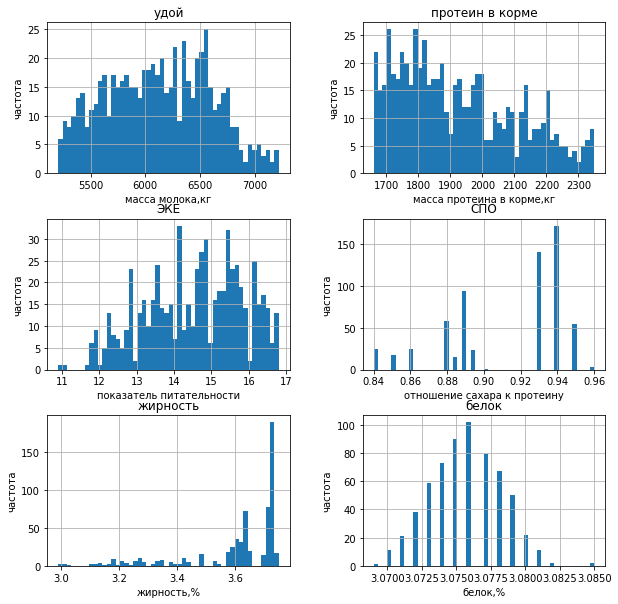

In [12]:
axes = ferma.hist(column=['milk','protein','energy','sugar_protein','fat_percent','protein_percent'],\
figsize=(10,10), bins=50)
x_labels = ['масса молока,кг','масса протеина в корме,кг','показатель питательности',\
'отношение сахара к протеину', 'жирность,%','белок,%']
titles = ['удой','протеин в корме','ЭКЕ','СПО', 'жирность','белок']
for i, ax in enumerate(axes.flatten()):
    ax.set_xlabel(x_labels[i])
    ax.set_ylabel('частота')
    ax.set_title(titles[i])

В результате исследования количественных значений таблицы ferma можно заметить следующие зависимости:

- значения в столбцах "удой", "белок" распределены нормально, есть небольшие выбросы; значение протеина в корме распределено практически нормально, но с небольшим смещением влево;
- остальные значения (в столбцах "жирность", "СПО", "ЭКЕ") не имеют нормального распределения.

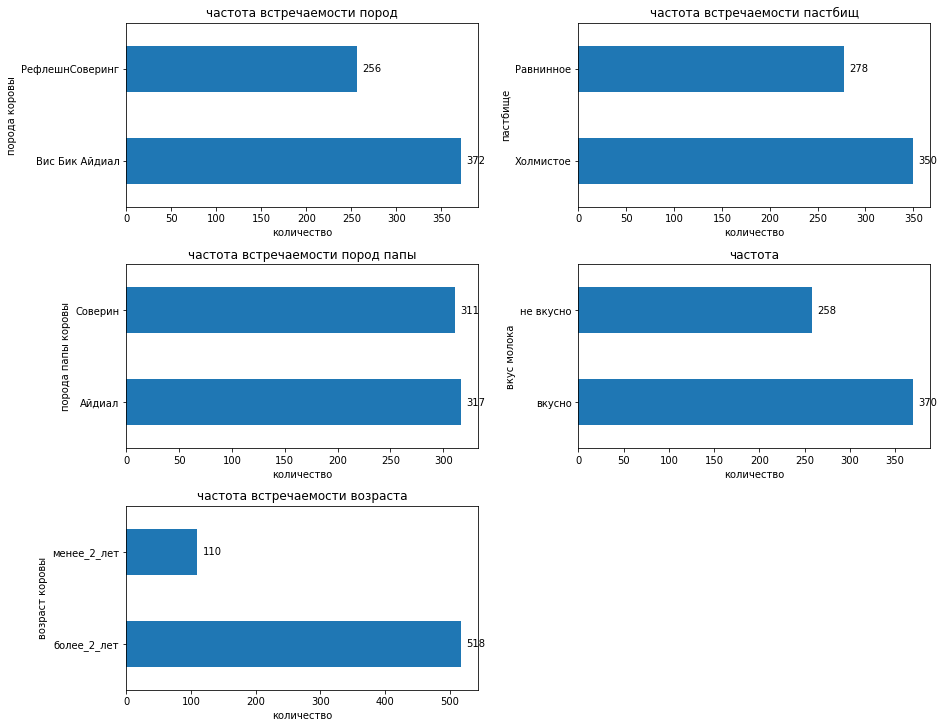

In [13]:
copy = ferma.copy()
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13,10), constrained_layout=True)
copy['breed'].value_counts().plot(kind='barh',ax=axes[0, 0], xlabel='порода коровы', \
title='частота встречаемости пород')
axes[0,0].set_xlabel('количество')
copy['pasture'].value_counts().plot(kind='barh',ax=axes[0, 1], xlabel='пастбище', \
title='частота встречаемости пастбищ')
axes[0,1].set_xlabel('количество')
copy['dad_breed'].value_counts().plot(kind='barh',ax=axes[1, 0], xlabel='порода папы коровы', \
title='частота встречаемости пород папы')
axes[1,0].set_xlabel('количество')
copy['is_tasty'].value_counts().plot(kind='barh',ax=axes[1, 1], xlabel='вкус молока', title='частота')
axes[1,1].set_xlabel('количество')
copy['age'].value_counts().plot(kind='barh',ax=axes[2, 0], xlabel='возраст коровы', \
title='частота встречаемости возраста')
axes[2,0].set_xlabel('количество')
fig.delaxes(axes[2,1])
for p in axes.flatten():
    for pi in p.patches:
        width = pi.get_width()
        p.annotate(f'{width}', (width, pi.get_y() + pi.get_height() / 2.),
                ha='left', va='center',
                xytext=(5,0),
                textcoords='offset points')
    

В результате исследования категориальных значений в таблице ferma можно заметить следующие зависимости:
- чаще встречаются коровы породы Вис Бик Айдиал (372), реже - породы РефлешнСоверинг(256);
- чаще встречаются коровы, которые пасутся на холмистом пастбище (350), реже - на равнинном (278);
- породы папы коровы - Соверин и Айдиал встречаются примерно одинаково (311 против 317)
- чаще всего молоко оказывается вкусным (370), нежели невкусным(258);
- большинство коров старше двух лет (518), коров возрастом меньше двух лет 110.

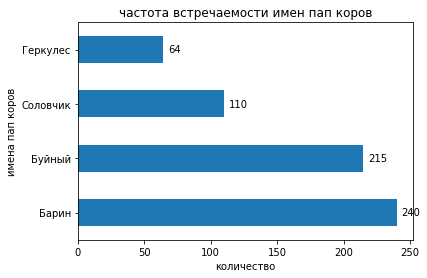

In [14]:
ax1 = ferma_dad['dad_name'].value_counts().plot(kind='barh', ylabel='имена пап коров', \
title='частота встречаемости имен пап коров')
ax1.set_xlabel('количество')
def names(ax):
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width}', (width, p.get_y() + p.get_height() / 2.),\
            ha='left', va='center',
            xytext=(5,0),
            textcoords='offset points')
names(ax1)

В результате исследования категориальных значений в таблице ferma_dad можно заметить следующую зависимость: чаще всего встречающееся имя папы коровы - Барин (240 значений), реже всего встречающееся - Геркулес (64 значения)

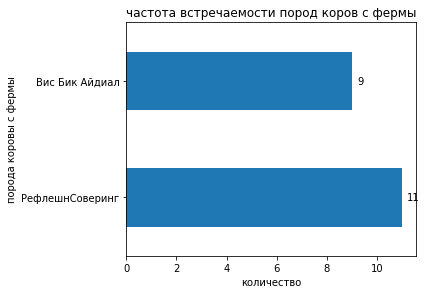

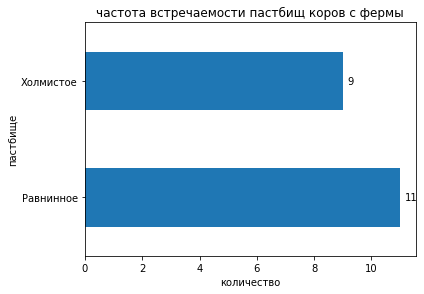

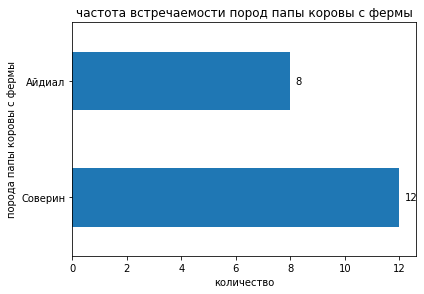

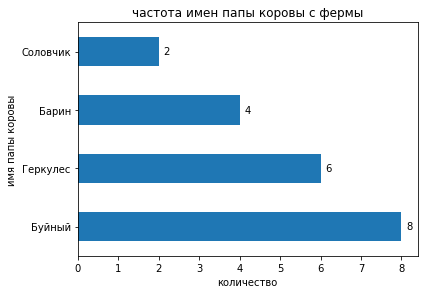

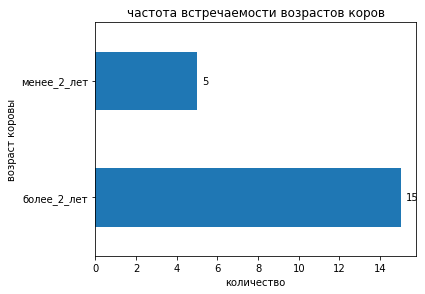

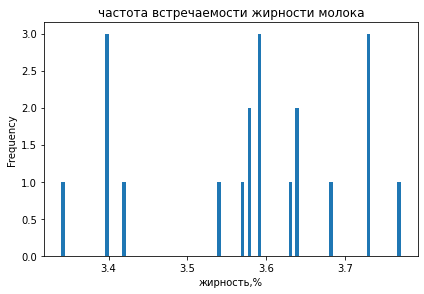

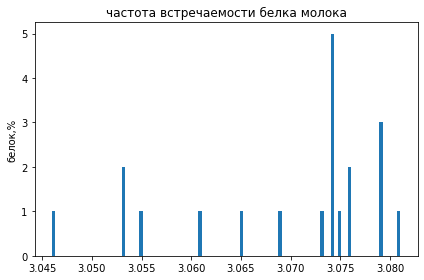

In [15]:
def graph(data, column, x_label, y_label, title, graph_type):
    if graph_type == 'hist':
        ax = data[column].plot(kind=graph_type, xlabel=x_label, ylabel=y_label, title=title, bins=100)
    elif graph_type == 'barh':
        ax = data[column].value_counts().plot(kind=graph_type, xlabel=x_label, ylabel=y_label, title=title)
        names(ax)
    plt.tight_layout()
    return ax
graph(cow, 'breed', 'порода коровы с фермы', 'количество', \
           'частота встречаемости пород коров с фермы','barh').set_xlabel('количество')
plt.show()
graph(cow, 'pasture', 'пастбище', 'количество', \
           'частота встречаемости пастбищ коров с фермы','barh').set_xlabel('количество')
plt.show()
graph(cow, 'dad_breed', 'порода папы коровы с фермы', 'количество', \
           'частота встречаемости пород папы коровы с фермы','barh').set_xlabel('количество')
plt.show()
graph(cow, 'dad_name', 'имя папы коровы', 'количество', \
           'частота имен папы коровы с фермы','barh').set_xlabel('количество')
plt.show()
graph(cow, 'age', 'возраст коровы', 'количество', \
           'частота встречаемости возрастов коров','barh').set_xlabel('количество')
plt.show()
graph(cow, 'fat_percent', 'жирность,%', 'частота встречаемости', \
           'частота встречаемости жирности молока','hist').set_xlabel('жирность,%')
plt.show()
graph(cow, 'protein_percent', 'белок,%', 'частота встречаемости', \
           'частота встречаемости белка молока','hist').set_ylabel('белок,%')
plt.show()

В результате исследования категориальных значений в таблице cow можно заметить следующие зависимости:
- породы коров с Экофермы распределены примерно поровну: 9 коров породы Вис Бик Айдиал, 11 коров породы РефлешнСоверинг;
- аналогичная ситуация с пастбищами - 11 коров с равнинных пастбищ, 9 с холмистых;
- у 12 коров порода папы Соверин, у 8 - Айдиал;
- больше всего коров, у которых имя папы - Буйный(8), меньше всего тех, у кого имя папы - Соловчик(2)

В результате исследования количественных значениях в таблице cow можно заметить следующие зависимости:
диапазон значений жирности молока и белка такой же, что и в основной таблице, явных выбросов/аномальных значений нет.

**Общий вывод по исследовательскому анализу данных:**

В данных есть незначительные выбросы, которые скорее всего не повлияют на результаты работы модели (т.к. все аномальные значения были удалены на этапе обработки данных). Также некоторые количественные значения не имеют нормального распределения. Распределение целевого признака - удоя - близко к нормальному.


## Корреляционный анализ

,id,milk,energy,protein,sugar_protein,breed,pasture,dad_breed,fat_percent,protein_percent,is_tasty,age
id,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
milk,1.0,1.000000,0.720719,0.463224,0.661359,0.164744,0.279540,0.519915,0.707654,0.058970,0.173122,0.998101
energy,1.0,0.720719,1.000000,0.456484,0.591190,0.123086,0.106758,0.171355,0.715914,0.000000,0.272265,0.771596
protein,1.0,0.463224,0.456484,1.000000,0.387188,0.090925,0.096474,0.000000,0.397380,0.202474,0.176480,0.351685
sugar_protein,1.0,0.661359,0.591190,0.387188,1.000000,0.062660,0.155349,0.425601,0.645581,0.073787,0.572702,0.744410
breed,1.0,0.164744,0.123086,0.090925,0.062660,1.000000,0.213218,0.089330,0.222825,0.361851,0.000000,0.057295
pasture,1.0,0.279540,0.106758,0.096474,0.155349,0.213218,1.000000,0.000000,0.000000,0.099908,0.269063,0.128455
dad_breed,1.0,0.519915,0.171355,0.000000,0.425601,0.089330,0.000000,1.000000,0.000000,0.134582,0.000000,0.355817
fat_percent,1.0,0.707654,0.715914,0.397380,0.645581,0.222825,0.000000,0.000000,1.000000,0.000000,0.198793,0.677913
protein_percent,1.0,0.058970,0.000000,0.202474,0.073787,0.361851,0.099908,0.134582,0.000000,1.000000,0.143857,0.000000


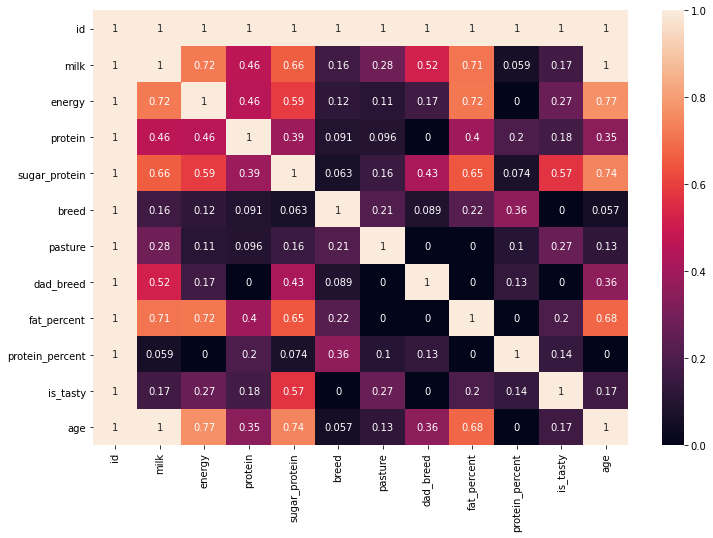

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(ferma.phik_matrix(interval_cols=['milk', 'energy', 'protein', 'sugar_protein', 'fat_percent',\
                                 'protein_percent']), annot=True)
ferma.phik_matrix(interval_cols=['milk', 'energy', 'protein', 'sugar_protein', 'fat_percent',\
                                 'protein_percent'])

<AxesSubplot:title={'center':'удой/белок'}, xlabel='удой, кг', ylabel='белок,%'>

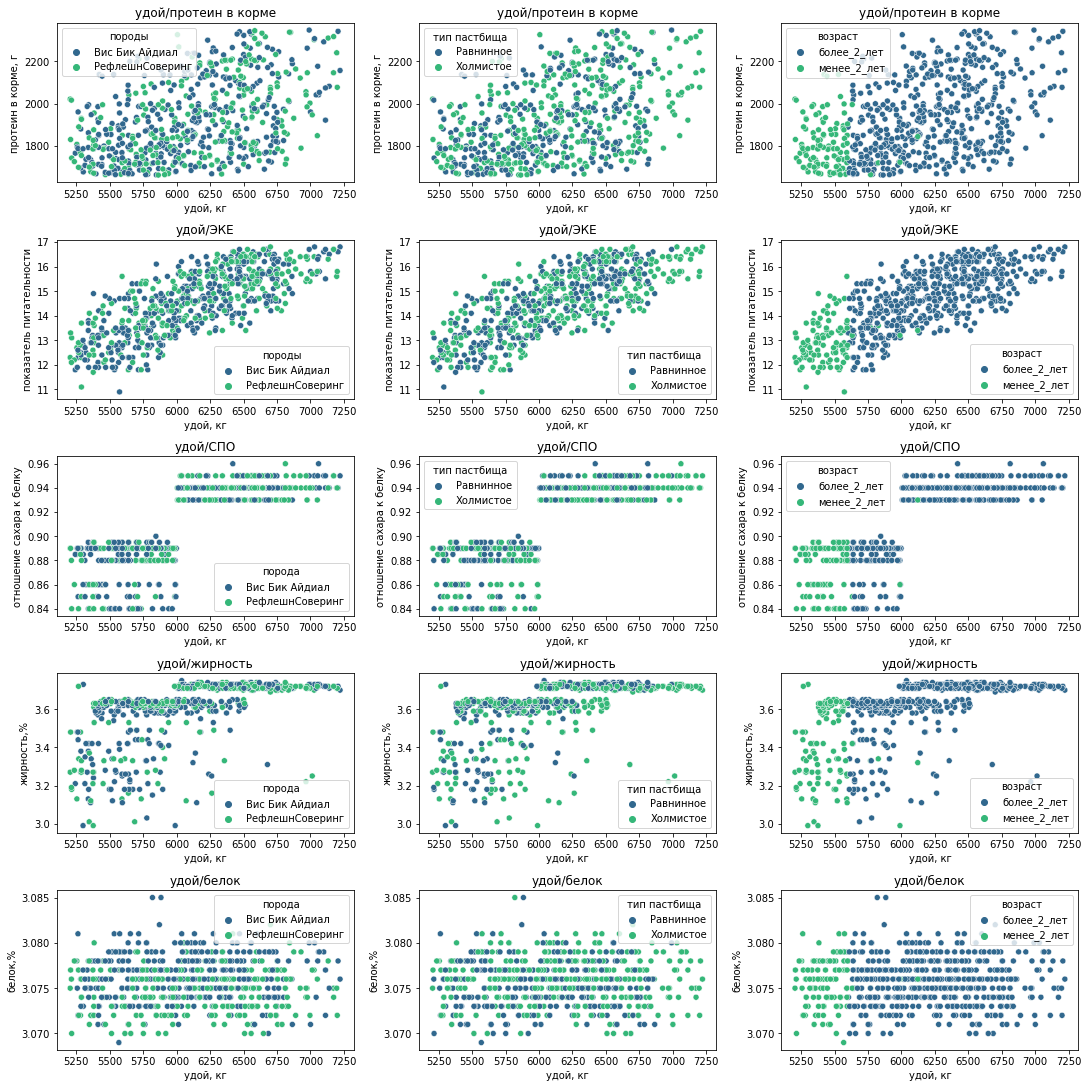

In [17]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15,15), constrained_layout=True)
def scatter_milk(y, hue, ax, xlabel, ylabel, title, legend):
    ax = sns.scatterplot(data=ferma, x='milk', y=y, hue=hue, palette='viridis', ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title=legend)
    return ax
scatter_milk('protein', 'breed', axes[0,0], 'удой, кг', 'протеин в корме, г', 'удой/протеин в корме',\
             'породы')
scatter_milk('protein', 'pasture', axes[0,1], 'удой, кг', 'протеин в корме, г', 'удой/протеин в корме',\
             'тип пастбища')
scatter_milk('protein', 'age', axes[0,2], 'удой, кг', 'протеин в корме, г', 'удой/протеин в корме',\
             'возраст')
scatter_milk('energy', 'breed', axes[1,0], 'удой, кг', 'показатель питательности', 'удой/ЭКЕ',\
             'породы')
scatter_milk('energy', 'pasture', axes[1,1], 'удой, кг', 'показатель питательности', 'удой/ЭКЕ',\
             'тип пастбища')
scatter_milk('energy', 'age', axes[1,2], 'удой, кг', 'показатель питательности', 'удой/ЭКЕ',\
             'возраст')
scatter_milk('sugar_protein', 'breed', axes[2,0], 'удой, кг', 'отношение сахара к белку', 'удой/СПО',\
             'порода')
scatter_milk('sugar_protein', 'pasture', axes[2,1], 'удой, кг', 'отношение сахара к белку', 'удой/СПО',\
             'тип пастбища')
scatter_milk('sugar_protein', 'age', axes[2,2], 'удой, кг', 'отношение сахара к белку', 'удой/СПО',\
             'возраст')
scatter_milk('fat_percent', 'breed', axes[3,0], 'удой, кг', 'жирность,%', 'удой/жирность',\
             'порода')
scatter_milk('fat_percent', 'pasture', axes[3,1], 'удой, кг', 'жирность,%', 'удой/жирность',\
             'тип пастбища')
scatter_milk('fat_percent', 'age', axes[3,2], 'удой, кг', 'жирность,%', 'удой/жирность',\
             'возраст')
scatter_milk('protein_percent', 'breed', axes[4,0], 'удой, кг', 'белок,%', 'удой/белок',\
             'порода')
scatter_milk('protein_percent', 'pasture', axes[4,1], 'удой, кг', 'белок,%', 'удой/белок',\
             'тип пастбища')
scatter_milk('protein_percent', 'age', axes[4,2], 'удой, кг', 'белок,%', 'удой/белок',\
             'возраст')

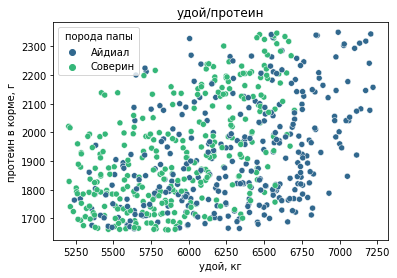

In [18]:
sns.scatterplot(data=ferma, x='milk', y='protein', hue='dad_breed', palette='viridis')
plt.xlabel('удой, кг')
plt.ylabel('протеин в корме, г')
plt.title('удой/протеин')
plt.legend(title='порода папы')

**В результате корреляционного анализа можно сделать следующие выводы:**
1) Целевой признак - удой ('milk') коррелирует с входными признаками 'energy' (показатель питательности корма коровы), 'sugar_protein' (сахаро-протеиновое отношение (характеристика корма)), 'fat_percent' (процент жирности молока), 'age'(возраст коровы), 'dad_breed' (порода папы)

2) Нелинейные связи между целевым и входными признаками встречаются: нелинейная связь между удоем и протеином в корме; между удоем и ЭКЕ (кривое облако - квадратичная зависимость); между удоем и СПО (наблюдается тенденция к кластеризации)

3) Коллинеарности между входными признаками не наблюдается, тк о мультиколлинеарности говорят, как правило, при коэффициенте корреляции 0,9 - 0,95. В наших данных коэффициент корреляции между признаками не превышает 0,8.

**Также, исходя из диаграмм рассеяния можно заметить следующие зависимости количественных и категориальных признаков:**

- у коров возрастом меньше 2-ух лет меньше удой, ЭКЕ, СПО корма, жирность и белок молока, чем у коров старше 2-ух лет
- удой коров, пасущихся на холмистом пастбище больше, чем на равнинном;
- удой, белок, жирность молока не зависит от породы коровы
- удой больше у тех коров, чьи папы породы Айдиал

## Обучение модели линейной регрессии

In [19]:
X1 = ferma.drop(['milk', 'is_tasty','protein_percent','id', 'fat_percent'], axis=1)
y1 = ferma['milk']

В качестве целевого признака используем удой, в качестве входных признаков: ЭКЕ, сырой протеин, СПО (т.к. качество корма коровы напрямую влияет на удой), порода папы коровы, тип пастбища, порода коровы и возраст (зависимость целевого признака от входных можно заметить на диаграммах рассеяния и в матрице корреляции).
Вкус молока, процент белка и жирность не влияют на удой, поэтому они не входят во входные признаки. (отсутствие влияния некоторых признаков можно заметить на диаграммах рассеяния)

Коэффициент детерминации модели: 0.7844078173416967


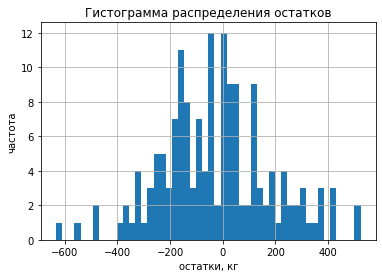

Text(0.5, 1.0, 'Диаграмма рассеяния остатков')

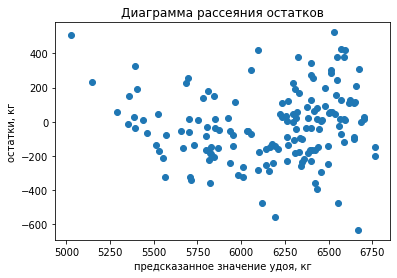

In [31]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=42)
category_cols = ['pasture', 'dad_breed', 'age', 'breed']
numeric_cols = ['protein', 'energy', 'sugar_protein']

encoder = OneHotEncoder(drop='first', sparse_output=False)
X1_train_ohe = encoder.fit_transform(X1_train[category_cols])
X1_test_ohe = encoder.transform(X1_test[category_cols])
encoder_col_names = encoder.get_feature_names_out()
X1_train_ohe = pd.DataFrame(X1_train_ohe, columns=encoder_col_names)
X1_test_ohe = pd.DataFrame(X1_test_ohe, columns=encoder_col_names)

scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train[numeric_cols])
X1_test_scaled = scaler.transform(X1_test[numeric_cols])
X1_train_scaled = pd.DataFrame(X1_train_scaled, columns=numeric_cols)
X1_test_scaled = pd.DataFrame(X1_test_scaled, columns=numeric_cols)

X1_train = pd.concat([X1_train_ohe, X1_train_scaled], axis=1)
X1_test = pd.concat([X1_test_ohe, X1_test_scaled], axis=1)

model_lr = LinearRegression()
model_lr.fit(X1_train, y1_train)
pred1 = model_lr.predict(X1_test)

r2_1 = r2_score(y1_test, pred1)#коэффициент детерминации первой модели
print(f'Коэффициент детерминации модели: {r2_1}')
lasts = y1_test - pred1
lasts.hist(bins=50)
plt.xlabel('остатки, кг')
plt.ylabel('частота')
plt.title('Гистограмма распределения остатков')
plt.show()
plt.scatter(x=pred1, y=lasts)
plt.xlabel('предсказанное значение удоя, кг')
plt.ylabel('остатки, кг')
plt.title('Диаграмма рассеяния остатков')

Первая модель: 

- коэффициент детерминации составляет примерно 0,8, это хороший результат, значит, модель хорошо предсказывает целевой признак
- анализ остатков: гистограмма показывает, что модель не достигла максимального качества, так как у остатков нет нормального распределения (распределение близко к нормальному, но есть некоторые "выбивающиеся" значения и выбросы); диаграмма распределения показывает чередование низкой и высокой дисперсии остатков, это говорит о том, что модель работает неустойчиво (при более высоком значении удоя большой разброс ошибок). Также по анализу остатков можно заметить, что модель немного завышает предсказания для низкого удоя
- в качестве дополнительных исследований были изменены входные признаки (пробовала добавить породу и процент протеина в молоке), но это не изменило диаграмму рассеяния.

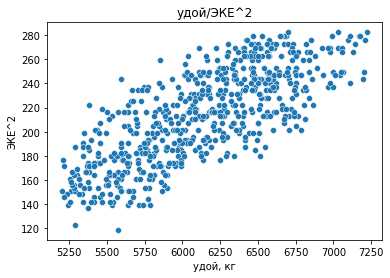

In [32]:
def category(row): #создаем функцию для создания нового бинарного признака
    if row > 0.91:
        return '1'
    else:
        return '0' 
ferma['sugar_protein_category'] = ferma['sugar_protein'].apply(category)
ferma['energy_2'] = ferma['energy'] ** 2
ax = sns.scatterplot(data=ferma, x='milk', y='energy_2')
ax.set_xlabel('удой, кг')
ax.set_ylabel('ЭКЕ^2')
ax.set_title('удой/ЭКЕ^2')
plt.show()


In [33]:
X2 = ferma.drop(['milk', 'energy', 'breed', 'protein_percent', 'is_tasty', 'sugar_protein','id'], axis=1)
y2 = ferma['milk']

Коэффициент детерминации модели: 0.8165458072190872


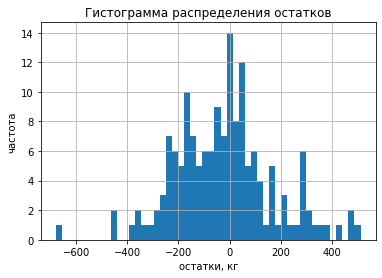

Text(0.5, 1.0, 'Диаграмма рассеяния остатков')

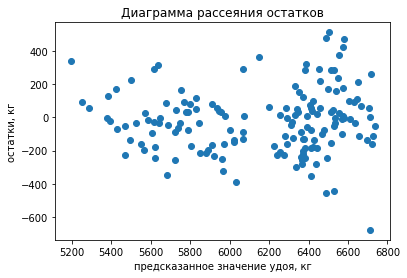

In [35]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, random_state=42)

category_cols = ['pasture', 'dad_breed', 'age', 'sugar_protein_category']
numeric_cols = ['protein', 'energy_2', 'fat_percent']

X2_train_ohe = encoder.fit_transform(X2_train[category_cols])
X2_test_ohe = encoder.transform(X2_test[category_cols])
encoder_col_names2 = encoder.get_feature_names_out()
X2_train_ohe = pd.DataFrame(X2_train_ohe, columns=encoder_col_names2)
X2_test_ohe = pd.DataFrame(X2_test_ohe, columns=encoder_col_names2)

X2_train_scaled = scaler.fit_transform(X2_train[numeric_cols])
X2_test_scaled = scaler.transform(X2_test[numeric_cols])
X2_train_scaled = pd.DataFrame(X2_train_scaled, columns=numeric_cols)
X2_test_scaled = pd.DataFrame(X2_test_scaled, columns=numeric_cols)

X2_train = pd.concat([X2_train_ohe, X2_train_scaled], axis=1)
X2_test = pd.concat([X2_test_ohe, X2_test_scaled], axis=1)

model_lr.fit(X2_train, y2_train)
pred2 = model_lr.predict(X2_test)

r2_2 = r2_score(y2_test, pred2)#коэффициент детерминации второй модели
print(f'Коэффициент детерминации модели: {r2_2}')
lasts2 = y2_test - pred2
lasts2.hist(bins=50)
plt.xlabel('остатки, кг')
plt.ylabel('частота')
plt.title('Гистограмма распределения остатков')
plt.show()
plt.scatter(x=pred2, y=lasts2)
plt.xlabel('предсказанное значение удоя, кг')
plt.ylabel('остатки, кг')
plt.title('Диаграмма рассеяния остатков')

Вторая модель:

- коэффициент детерминации повысился по сравнению с первой моделью и стал составлять примерно 0,83;
- по анализу остатков: на гистограмме уже четче видна картина нормального распределения, выбросов стало немного меньше по сравнению с первой моделью, на диаграмме рассеяния ситуация тоже улучшилась - 2 кластера остались, но разброс ошибок стал намного меньше.

In [36]:
ferma = ferma.merge(ferma_dad, how='left') #добавляем данные об имени папы
print(ferma.isna().sum()) #количество пропусков в таблице в результате объединения
ferma.head()
ferma.phik_matrix()

id                        0
milk                      0
energy                    0
protein                   0
sugar_protein             0
breed                     0
pasture                   0
dad_breed                 0
fat_percent               0
protein_percent           0
is_tasty                  0
age                       0
sugar_protein_category    0
energy_2                  0
dad_name                  0
dtype: int64
interval columns not set, guessing: ['milk', 'energy', 'protein', 'sugar_protein', 'fat_percent', 'protein_percent', 'energy_2']


,id,milk,energy,protein,sugar_protein,breed,pasture,dad_breed,fat_percent,protein_percent,is_tasty,age,sugar_protein_category,energy_2,dad_name
id,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
milk,1.0,1.000000,0.720719,0.463224,0.661359,0.164744,0.279540,0.519915,0.707654,0.058970,0.173122,0.998101,0.999947,0.722116,0.433409
energy,1.0,0.720719,1.000000,0.456484,0.591190,0.123086,0.106758,0.171355,0.715914,0.000000,0.272265,0.771596,0.900428,0.979902,0.069197
protein,1.0,0.463224,0.456484,1.000000,0.387188,0.090925,0.096474,0.000000,0.397380,0.202474,0.176480,0.351685,0.537071,0.451582,0.111229
sugar_protein,1.0,0.661359,0.591190,0.387188,1.000000,0.062660,0.155349,0.425601,0.645581,0.073787,0.572702,0.744410,1.000000,0.584376,0.409142
breed,1.0,0.164744,0.123086,0.090925,0.062660,1.000000,0.213218,0.089330,0.222825,0.361851,0.000000,0.057295,0.028933,0.074709,0.382644
pasture,1.0,0.279540,0.106758,0.096474,0.155349,0.213218,1.000000,0.000000,0.000000,0.099908,0.269063,0.128455,0.143022,0.148222,0.233149
dad_breed,1.0,0.519915,0.171355,0.000000,0.425601,0.089330,0.000000,1.000000,0.000000,0.134582,0.000000,0.355817,0.407797,0.152239,0.982909
fat_percent,1.0,0.707654,0.715914,0.397380,0.645581,0.222825,0.000000,0.000000,1.000000,0.000000,0.198793,0.677913,0.922373,0.714925,0.090409
protein_percent,1.0,0.058970,0.000000,0.202474,0.073787,0.361851,0.099908,0.134582,0.000000,1.000000,0.143857,0.000000,0.000000,0.000000,0.091102


In [37]:
X3 = ferma.drop(['breed', 'milk', 'protein_percent', 'is_tasty', 'energy', 'sugar_protein', 'id',\
                'dad_breed'], axis=1)
y3 = ferma['milk']

Коэффициент детерминации модели: 0.8224363807923109


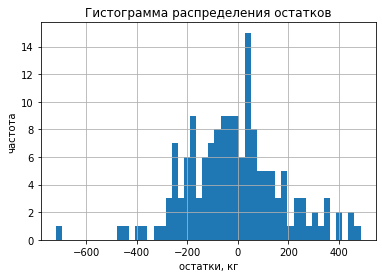

Text(0.5, 1.0, 'Диаграмма рассеяния остатков')

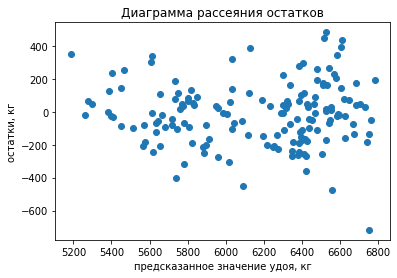

In [39]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, random_state=42)
category_cols = ['pasture', 'age', 'sugar_protein_category', 'dad_name']
numeric_cols = ['protein', 'energy_2', 'fat_percent']

X3_train_ohe = encoder.fit_transform(X3_train[category_cols])
X3_test_ohe = encoder.transform(X3_test[category_cols])
encoder_col_names3 = encoder.get_feature_names_out()
X3_train_ohe = pd.DataFrame(X3_train_ohe, columns=encoder_col_names3)
X3_test_ohe = pd.DataFrame(X3_test_ohe, columns=encoder_col_names3)

X3_train_scaled = scaler.fit_transform(X3_train[numeric_cols])
X3_test_scaled = scaler.transform(X3_test[numeric_cols])
X3_train_scaled = pd.DataFrame(X3_train_scaled, columns=numeric_cols)
X3_test_scaled = pd.DataFrame(X3_test_scaled, columns=numeric_cols)

X3_train = pd.concat([X3_train_ohe, X3_train_scaled], axis=1)
X3_test = pd.concat([X3_test_ohe, X3_test_scaled], axis=1)

model_lr.fit(X3_train, y3_train)
pred3 = model_lr.predict(X3_test)

r2_3 = r2_score(y3_test, pred3)#коэффициент детерминации третьей модели
print(f'Коэффициент детерминации модели: {r2_3}')
lasts3 = y3_test - pred3
lasts3.hist(bins=50)
plt.xlabel('остатки, кг')
plt.ylabel('частота')
plt.title('Гистограмма распределения остатков')
plt.show()
plt.scatter(x=pred3, y=lasts3)
plt.xlabel('предсказанное значение удоя, кг')
plt.ylabel('остатки, кг')
plt.title('Диаграмма рассеяния остатков')

Третья модель:

- коэффициент детерминации увеличился по сравнению с остальными двумя моделями и составляет примерно 0, 84;
- анализ остатков: гистограмма распределения еще больше похоже на нормальное, это означает, что модель практически достигла максимального качества, анализ диаграммы рассеяния показывает все те же проблемы - модель хуже предсказывает удой больше 6000 кг (чаще ошибается)

In [44]:
def metrics(y_true, y_pred):
    return mean_squared_error(y_true, y_pred), root_mean_squared_error(y_true, y_pred)
mse1, rmse1 = metrics(y1_test, pred1)
mse2, rmse2 = metrics(y2_test, pred2)
mse3, rmse3 = metrics(y3_test, pred3)
results = {'mse': [mse1, mse2, mse3], 'rmse': [rmse1, rmse2, rmse3], 'r2': [r2_1, r2_2, r2_3]}
results = pd.DataFrame(data=results, index=['first model', 'second model', 'third model'])
results

,mse,rmse,r2
first model,43887.015010,209.492279,0.784408
second model,37344.846241,193.248147,0.816546
third model,36145.731841,190.120309,0.822436


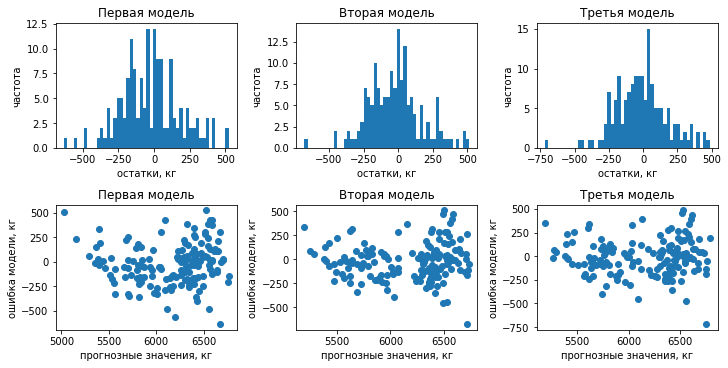

In [45]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10,5), constrained_layout=True)
axes[0,0].hist(lasts, bins=50)
axes[0,0].set_title('Первая модель')
axes[0,1].hist(lasts2, bins=50)
axes[0,1].set_title('Вторая модель')
axes[0,2].hist(lasts3, bins=50)
axes[0,2].set_title('Третья модель')
for i in range(3):
    for ax in axes:
        axes[0,i].set_xlabel('остатки, кг')
        axes[0,i].set_ylabel('частота')
axes[1,0].scatter(x=pred1, y=lasts)
axes[1,0].set_title('Первая модель')
axes[1,1].scatter(x=pred2, y=lasts2)
axes[1,1].set_title('Вторая модель')
axes[1,2].scatter(x=pred3, y=lasts3)
axes[1,2].set_title('Третья модель')
for i in range(3):
    for ax in axes:
        axes[1,i].set_xlabel('прогнозные значения, кг')
        axes[1,i].set_ylabel('ошибка модели, кг')

По результатам исследования можно сделать вывод, что лучше всего прогнозирует удой молока третья модель. У нее наилучшие метрики качества модели. Анализ остатков, а конкретно гистограмма распределения остатков доказывает, что эта модель достигла максимального качества (так как распределение остатков длизко к нормальному), диаграмма рассеяния также подтверждает высокое качество модели - ошибки распределены равномерно, дисперсия остатков примерно одинакова и на больших, и на маленьких значениях удоя. Тем не менее, модель на низких показателях немного завышает прогнозы и следовательно остается немного неточной.

In [46]:
interval = (np.percentile(lasts3, 2.5), np.percentile(lasts3, 97.5))
print(f'Доверительный интервал прогноза лучшей модели: {interval}')

Доверительный интервал прогноза лучшей модели: (-363.5204999368212, 390.1680104012197)


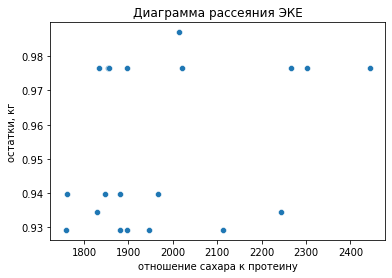

,breed,pasture,dad_breed,dad_name,fat_percent,protein_percent,age,energy,protein,sugar_protein,sugar_protein_category,energy_2
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,14.91,1830.15,0.93450,0,222.3081
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,13.44,2244.90,0.93450,0,180.6336
2,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,14.70,1946.70,0.92925,0,216.0900
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,13.02,2112.60,0.92925,0,169.5204
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,13.44,1758.75,0.92925,0,180.6336


In [47]:
cow['energy'] = ferma['energy'] * 1.05
cow['protein'] = ferma['protein'] * 1.05
cow['sugar_protein'] = ferma['sugar_protein'] * 1.05
sns.scatterplot(data=cow, x='protein', y='sugar_protein')
plt.xlabel('отношение сахара к протеину')
plt.ylabel('остатки, кг')
plt.title('Диаграмма рассеяния ЭКЕ')
plt.show()
#диаграмма рессеяния для дальнейшей категоризации признака
def category(row): #создаем функцию для создания нового бинарного признака
    if row > 0.96:
        return '1'
    else:
        return '0' 
cow['sugar_protein_category'] = cow['sugar_protein'].apply(category)
cow['energy_2'] = cow['energy'] ** 2
cow.head()

In [50]:
# подготовка данных
category_cols = ['pasture', 'age', 'sugar_protein_category', 'dad_name']
numeric_cols = ['protein', 'energy_2', 'fat_percent']
cow_for_predict = cow[['protein', 'pasture', 'age','fat_percent',\
                      'sugar_protein_category', 'energy_2', 'dad_name']]
cow_for_predict_ohe = encoder.transform(cow_for_predict[category_cols])
encoder_col_names_result = encoder.get_feature_names_out()
cow_for_predict_ohe = pd.DataFrame(cow_for_predict_ohe, columns=encoder_col_names_result)

cow_for_predict_scaled = scaler.transform(cow_for_predict[numeric_cols])
cow_for_predict_scaled = pd.DataFrame(cow_for_predict_scaled, columns=numeric_cols)

cow_for_predict = pd.concat([cow_for_predict_ohe, cow_for_predict_scaled], axis=1)

# подготовка модели
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, random_state=42)
category_cols = ['pasture', 'age', 'sugar_protein_category', 'dad_name']
numeric_cols = ['protein', 'energy_2', 'fat_percent']

X3_train_ohe = encoder.fit_transform(X3_train[category_cols])
X3_test_ohe = encoder.transform(X3_test[category_cols])
encoder_col_names3 = encoder.get_feature_names_out()
X3_train_ohe = pd.DataFrame(X3_train_ohe, columns=encoder_col_names3)
X3_test_ohe = pd.DataFrame(X3_test_ohe, columns=encoder_col_names3)

X3_train_scaled = scaler.fit_transform(X3_train[numeric_cols])
X3_test_scaled = scaler.transform(X3_test[numeric_cols])
X3_train_scaled = pd.DataFrame(X3_train_scaled, columns=numeric_cols)
X3_test_scaled = pd.DataFrame(X3_test_scaled, columns=numeric_cols)

X3_train = pd.concat([X3_train_ohe, X3_train_scaled], axis=1)
X3_test = pd.concat([X3_test_ohe, X3_test_scaled], axis=1)

model_lr.fit(X3_train, y3_train)
milk_result = model_lr.predict(cow_for_predict)
cow['milk'] = milk_result #получаем предсказание удоя и добавляем в датафрейм cow
cow.head()

,breed,pasture,dad_breed,dad_name,fat_percent,protein_percent,age,energy,protein,sugar_protein,sugar_protein_category,energy_2,milk
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,14.91,1830.15,0.93450,0,222.3081,6164.393143
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,13.44,2244.90,0.93450,0,180.6336,5839.570001
2,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,14.70,1946.70,0.92925,0,216.0900,5822.991647
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,13.02,2112.60,0.92925,0,169.5204,5964.672474
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,13.44,1758.75,0.92925,0,180.6336,5906.549584


In [51]:
print('Число подходящих под критерий удоя коров:', len(cow[cow['milk'] > 6000]))
cow[cow['milk'] >= 6000]

Число подходящих под критерий удоя коров: 12


,breed,pasture,dad_breed,dad_name,fat_percent,protein_percent,age,energy,protein,sugar_protein,sugar_protein_category,energy_2,milk
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,14.910,1830.15,0.93450,0,222.308100,6164.393143
6,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,13.860,1881.60,0.92925,0,192.099600,6057.332542
7,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.435,1896.30,0.97650,1,238.239225,6493.674812
8,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,14.910,2013.90,0.98700,1,222.308100,6199.593694
11,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,17.325,2444.40,0.97650,1,300.155625,6953.041519
12,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.68,3.046,более_2_лет,16.170,2302.65,0.97650,1,261.468900,6805.139513
13,Вис Бик Айдиал,Холмистое,Соверин,Барин,3.42,3.075,менее_2_лет,15.225,1854.30,0.97650,1,231.800625,6035.776823
14,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,16.800,1857.45,0.97650,1,282.240000,6397.116513
15,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.065,более_2_лет,16.380,1834.35,0.97650,1,268.304400,6617.946119
17,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.77,3.053,менее_2_лет,16.485,2266.95,0.97650,1,271.755225,6620.182170


**Вывод:**

Третья модель обучена на исходных данных в таблице ferma, результат прогноза целевого признака (удой) был добавлен в таблицу cow. Качество итоговой третьей модели оказалось наивысшее среди трех (коэффициент детерминации составляет примерно 0,82). Анализ остатков такой модели также показал хорошие результаты: в отличие от других моделей гистограмма распределения остатков больше всего напоминает нормальное распределение, это означает, что модель практически достигла максимального качества, также анализ диаграммы рассеяния остатков показал, что у модели высокое качество - остутствует чередование низкой и высокой дисперсии остатков. Однако, низкие значения удоя эта модель предсказывает не идеально, иногда она модет завысить значение. По сравнению с остальными моделями она работает лучше всех.

В результате использования модели на данных о коровах с Экофермы было спрогнозировано значение удоя. Оказалось, что 12 коров из 20 подходят под условие об удое не менее 6000 кг. 

## Обучение модели логистической регрессии

accuracy с порогом 0.5: 0.6984126984126984
recall с порогом 0.5: 0.8292682926829268
precision с порогом 0.5: 0.7391304347826086


Text(0.5, 15.0, 'Предсказанная категория')

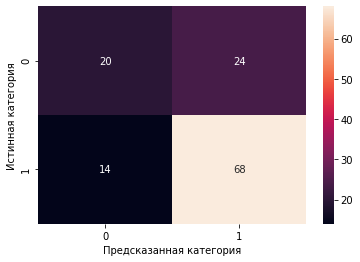

In [53]:
ferma['is_tasty_new'] = ferma['is_tasty'].apply(lambda x: 1 if x =='вкусно' else 0)
X = ferma.drop(['is_tasty_new', 'id', 'milk', 'energy', 'sugar_protein', 'is_tasty'], axis=1)
y = ferma['is_tasty_new']

# формируем тренировочную, валидационную и тестовую выборки
X_train, X_test1, y_train, y_test1 = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test1, y_test1, test_size=0.5, random_state=42)

category_cols = ['breed', 'pasture', 'dad_breed', 'age', 'sugar_protein_category', 'dad_name']
numeric_cols = ['protein', 'fat_percent', 'protein_percent', 'energy_2']

X_train_ohe = encoder.fit_transform(X_train[category_cols])
X_test_ohe = encoder.fit_transform(X_test[category_cols])
X_val_ohe = encoder.fit_transform(X_val[category_cols])
encored_cols_names = encoder.get_feature_names_out()
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encored_cols_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encored_cols_names)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=encored_cols_names)

X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.fit_transform(X_test[numeric_cols])
X_val_scaled = scaler.fit_transform(X_val[numeric_cols])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_cols)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=numeric_cols)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
X_val = pd.concat([X_val_ohe, X_val_scaled], axis=1)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred_val = clf.predict(X_val)


y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f'accuracy с порогом 0.5: {accuracy}')
print(f'recall с порогом 0.5: {recall}')
print(f'precision с порогом 0.5: {precision}')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.ylabel('Истинная категория')
plt.xlabel('Предсказанная категория')

При покупке коров критичнее всего ошибки первого рода (т.е. false positive должно быть как можно меньше). Соответственно метрика precision в условии этой задачи важнее.

После обучения модели на тренировочной выборке и проверки качества на тестовой были посчитаны следующие метрики при пороге классификации 0,5 (значение по умолчанию):

accuracy: 0.7
recall: 0.83
precision: 0.74

Можно заметить, что метрика precision недостаточно высока, а также в матрице ошибок достаточно много false positive (их 24, для сравнения ошибок false negative 14). Это означает, что порог классификации 0,5 не подходит в условиях данной задачи и его нужно увеличить.


recall X_val 0.1: 1.0
recall X_val 0.32: 0.9384615384615385
recall X_val 0.55: 0.7692307692307693
recall X_val 0.78: 0.2153846153846154
precision X_val 0.78: 0.7368421052631579
accuracy X_test с порогом 0.78: 0.4523809523809524
recall X_test с порогом 0.78: 0.18292682926829268
precision X_test с порогом 0.78: 0.8823529411764706


,предсказание без учета порога,вероятность принадлежности к классу 1,результат с учетом порога,истинное значение
0,1,0.537501,0,0
1,1,0.870759,1,1
2,1,0.697512,0,0
3,1,0.739457,0,1
4,1,0.558297,0,1


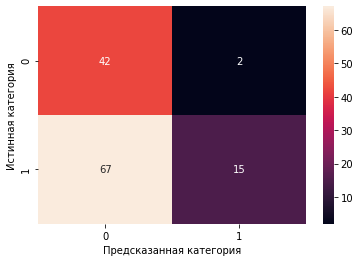

In [54]:
# создаем датафрейм с различными порогами
check_data = pd.DataFrame(y_pred_val, columns=['y_pred_val 0.5']) 
y_proba_val = clf.predict_proba(X_val)[:, 1]
check_data['y_proba'] = y_proba_val
#изучаем как влияют пороги на итоговые метрики
thresholds = [round(i,2) for i in np.linspace(0.1, 1, num=4, endpoint=False)]
for i in thresholds:
    check_data['new_pred ' + str(i)] = check_data['y_proba'].apply(lambda x: 1 if x >=i else 0)
check_data['y_true'] = y_val.reset_index(drop=True)

# считаем метрики для подбора подходящего порога
print(f'recall X_val 0.1: {recall_score(check_data["y_true"], check_data["new_pred 0.1"])}')
print(f'recall X_val 0.32: {recall_score(check_data["y_true"], check_data["new_pred 0.32"])}')
print(f'recall X_val 0.55: {recall_score(check_data["y_true"], check_data["new_pred 0.55"])}')
print(f'recall X_val 0.78: {recall_score(check_data["y_true"], check_data["new_pred 0.78"])}')
print(f'precision X_val 0.78: {precision_score(check_data["y_true"], check_data["new_pred 0.78"])}')

y_pred = clf.predict(X_test)
#исправляем некоторые значения с учетом порога
y_proba = clf.predict_proba(X_test)[:, 1]

data_test = pd.DataFrame({'предсказание без учета порога':y_pred,\
                          'вероятность принадлежности к классу 1':y_proba})
data_test['результат с учетом порога'] = data_test['вероятность принадлежности к классу 1'].apply(\
                                                                lambda x: 1 if x >= 0.78 else 0)
data_test['истинное значение'] = y_test.reset_index(drop=True) 

accuracy = accuracy_score(y_test, data_test['результат с учетом порога'])
recall = recall_score(y_test, data_test['результат с учетом порога'])
precision = precision_score(y_test, data_test['результат с учетом порога'])

print(f'accuracy X_test с порогом 0.78: {accuracy}')
print(f'recall X_test с порогом 0.78: {recall}')
print(f'precision X_test с порогом 0.78: {precision}')

cm = confusion_matrix(y_test, data_test['результат с учетом порога'])
sns.heatmap(cm, annot=True)
plt.ylabel('Истинная категория')
plt.xlabel('Предсказанная категория')
data_test.head()

В результате исследования было определено, что порог, необходимый для более точной класификации, составляет 0,78. Благодаря такому порогу значение precision максимально (порог можно сделать еще выше, но тогда уменьшается метрика accuracy и повышается количество FN).

В результате метрики для тестовой выборки при пороге 0,78:

accuracy = 0.48

recall = 0.16

precision = 0.86.

In [56]:
cow_for_predict2 = cow[['protein', 'breed', 'pasture', 'dad_breed', 'age', 'fat_percent', 'protein_percent',\
                 'sugar_protein_category', 'energy_2', 'dad_name']]
category_cols = ['breed', 'pasture', 'dad_breed', 'age', 'sugar_protein_category', 'dad_name']
numeric_cols = ['protein', 'fat_percent', 'protein_percent', 'energy_2']

cow_for_predict2_ohe = encoder.transform(cow_for_predict2[category_cols])
encoder_col_names_result2 = encoder.get_feature_names_out()
cow_for_predict2_ohe = pd.DataFrame(cow_for_predict2_ohe, columns=encoder_col_names_result2)

cow_for_predict2_scaled = scaler.transform(cow_for_predict2[numeric_cols])
cow_for_predict2_scaled = pd.DataFrame(cow_for_predict2_scaled, columns=numeric_cols)

cow_for_predict2 = pd.concat([cow_for_predict2_ohe, cow_for_predict2_scaled], axis=1)

is_tasty_result = clf.predict(cow_for_predict2)
cow['pred'] =  clf.predict_proba(cow_for_predict2)[:, 1]#результат без учета порога

cow['is_tasty'] = cow['pred'].apply(lambda x: 1 if x >=0.78 else 0)

In [57]:
print('Количество коров, подходящих под критерий вкуса молока:', len(cow[cow['is_tasty'] == 1]))
cow[cow['is_tasty'] == 1]

Количество коров, подходящих под критерий вкуса молока: 2


,breed,pasture,dad_breed,dad_name,fat_percent,protein_percent,age,energy,protein,sugar_protein,sugar_protein_category,energy_2,milk,pred,is_tasty
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,14.910,1830.15,0.9345,0,222.308100,6164.393143,0.794341,1
11,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,17.325,2444.40,0.9765,1,300.155625,6953.041519,0.868025,1


**Вывод:**

Модель логистической регрессии была обучена на основе данных датафрйма ferma. В результате тестирования модели было замечено, что модель часто допускает ошибки false negative, что недопустимо в условиях данной задачи, поэтому порог классификации был поднят до 0,78. Это помогло повысить метрику качества precision (она стала составлять 0,86)

Затем модель была применена на данных cow для предсказания целевого признака (вкус молока). В результате оказалось, что у двух коров с большой вероятностью окажется вкусное молоко, у остальных - невкусное.

Итоговая таблица коров, подходящих под два критерия (удой не менее 6000 кг и вкусное молоко), выведена ниже.

In [58]:
cow_result = cow[(cow['is_tasty'] == 1) & (cow['milk'] > 6000)]
cow_result

,breed,pasture,dad_breed,dad_name,fat_percent,protein_percent,age,energy,protein,sugar_protein,sugar_protein_category,energy_2,milk,pred,is_tasty
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,14.910,1830.15,0.9345,0,222.308100,6164.393143,0.794341,1
11,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,17.325,2444.40,0.9765,1,300.155625,6953.041519,0.868025,1


## Итоговые выводы

**В качестве исходных данных были переданы 3 датафрейма:**
- ferma_main.csv - содержит данные о стаде фермера на данный момент
- ferma_dad.csv - содержит данные о папе каждой коровы в стаде фермера
- cow_buy.csv - данные о коровах Экофермы 

**Предобработка данных:**

В исходных данных были обнаружены и обработаны следующие проблемы:
- явные дубликаты (были обнаружены в таблицах ferma_main и cow_buy); в таблице cow явные дубликаты были оставлены, так как исходных данных немного и скорее всего эти строки и не являются дубликатами
- неверный тип данных (столбец 'id' содержит категориальные признаки, но он был типа данных int)
- неявные дубликаты: неявные дубликаты были обнаружены в столбцах "пастбище" и "порода папы коровы" датафрейма ferma_main(Пример: "равнинные" и "равнинное ", "Айдиалл" и "Айдиал")

**Исследовательский анализ данных:**

В результате исследовательского анализа данных были обнаружены следующие зависимости:
- большинство количественных значений таблицы ferma_main распределены нормально, в некоторых значениях присутствуют выбросы 
- большинство коров фермера возрастом старше двух лет(518 против 110); чаще всего молоко коров вкусное(370 против 258); большинство коров пасутся на холмистом пастбище (350 против 278)
- большинство коров Экофермы возраста старше двух лет (15 против 5)
- 11 коров экофермы пасутся на равнинных пастбищах, 9 - на холмистых

**Корреляционный анализ:**

В результате корреляционного анализа были обнаружены следующие зависимости:
- целевые признаки (удой и вкус молока) коррелируют с входными признаками, однако с некоторыми выходными признаками можно заметить нелинейную зависимость
- мультиколлинеарность среди входных признаков отсутствует: входные признаки слабо коррелируют друг с другом
- По диаграмме рассеяния сахаро–протеинового отношения зависимости от удоя можно заметить что, тип данных этого признака можно будет изменить на категориальный, так как значения на диаграмме разделены на два кластера, прослеживается явное разделение между ними

**Обучение моделей линейной и логистической регрессий:**

В ходе анализа были созданы три модели линейной регрессии, каждая была обучена на тренировочной выборке и протестирована на тестовой, были посчитаны метрики качества модели, проведён анализ остатков. Третья модель лучше всех предсказывала данные и меньше ошибалась, поэтому она была использована для предсказания удоя коров с Экофермы. Столбец "milk" с предсказанными значениями был добавлен в исходную таблицу. Оказалось, что 12 коров подходят под критерий удоя не меньше 6000 кг.

Для предсказания категориального признака была создана, обучена на тренировочных данных, доработана на валидационных (был повышен порог классификации с 0,5 до 0,78) и протестирована на тестовой выборке модель логистической регрессии. С помощью этой модели впоследствии был определен искомый категориальной признак "вкус молока" коров с Экофермы. Оказалось, что 2 коровы подходят под критерий вкуса молока.

**Выводы о работе линейной регрессии:**

- в этой задаче использовались следующие способы улучшения качества регрессионной модели: измнение типа данных (количественные данные были изменены на категориальные); рассмотрение величины (ЭКЕ) в квадрате, это помогло увеличить линейную зависимость между целевым и входным признаком; изменение порога классификации (это помогло уменьшить количество ошибок false positive)
- мне кажется, что улучшить результаты качества регрессионной модели можно добавлением дополнительного признака о корме коровы, так как параметры корма оказывают большее влияние на целевой признак и как следствие они могут улучшить качество модели
- в основном важны метрики recall и precision. В каждой конкретной задачи классификации нужно принимать решение о том, какую метрику важно повысить, а какую наоборот уменьшить

**Рекомендации о повышении качества работа логистической регрессии:**

- повысить качество работы логистической регрессии может помочь добавление новых входных признаков (например, возможно, у некоторых коров есть заболевания, о которых стоит упомянуть либо возможно у каких-то коров были особые условия содержания)

**Результаты работы моделей для фермера:**

Фермер может купить для себя с минимальным риском только две коровы. Если он купит больше коров, то повысится вероятность того, что их молоко будет невкусное. В данных Экофермы оказалось мало коров, чье молоко оказалось вкусное (2 коровы).

